# Safety-Warning-RAG

This notebook extends the offline CV-RAG pattern from troubleshooting to safety-warning advisory. It demonstrates one image that should trigger an immediate safety warning and one image that should remain a QA/coordination follow-up.

**Scope boundary:** This remains a batch photo-based A10/edge-style simulation. It does not perform real-time video monitoring, autonomous stop-work enforcement, or competent-person approval.


## Offline safety-warning execution path

The safety-warning flow stays within the same A10/edge-style simulation used by the local notebook: local visual context, local retrieval, a deterministic policy gate, and Phi-4-mini ONNX CPU/mobile for the final advisory wording. The policy gate decides whether to issue a warning; the SLM drafts a concise, evidence-cited message.


Offline safety-warning advisory path Worker photo + question Local visual caption/body CLIP image/text embedding Local vector case retrieval Retrieved evidence with severity Deterministic safety gate Phi-4-mini advisory wording Human escalation and inspection QA / coordination follow-up path

## Clean report locations

| Artifact | Path |
| --- | --- |
| Safety warning report | `notebooks/reports/safety_warning_rag/safety_warning_demo_report.json` |
| Notebook | `notebooks/Safety-Warning-RAG.ipynb` |
| Positive held-out query image | `notebooks/assets/real_local_inference/query_images/` |
| Indexed case images | `notebooks/assets/cv_rag_enriched/images/` |


## Scenario setup and policy gate

| Scenario | Top local evidence | Severity | Matched policy keywords | Warning required | Expected |
| --- | --- | --- | --- | --- | --- |
| Safety issue detected: open slab edge beside scaffold access | INC-005 - Unsafe open edge adjacent to scaffold access point (`0.8029`) | critical | fall hazard, fall exposure, edge protection, scaffold, stop access | True | True |
| No immediate safety warning: MEP coordination clash | INC-004 - MEP duct coordination clash at ceiling void (`1.0000`) | medium | none | False | False |


Policy field,Value
Warning required,True
Risk level,critical
Matched keywords,"fall hazard, fall exposure, edge protection, scaffold, stop access"
Policy action,Issue safety warning and require escalation/controls before work continues.
Policy field,Value
Warning required,False
Risk level,no-immediate-safety-warning
Matched keywords,none
Policy action,Do not issue an immediate safety warning; route as QA/coordination follow-up with normal escalation triggers.

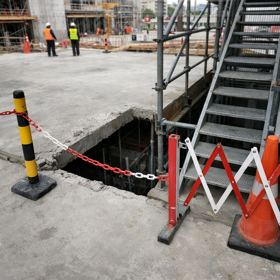
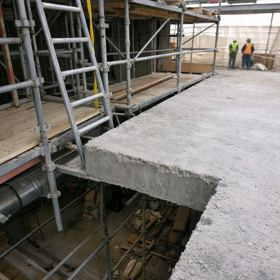
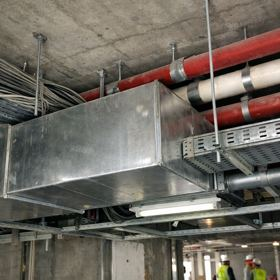
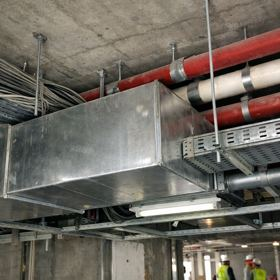

In [2]:
from IPython.display import HTML, display
display(HTML(safety_warning_demo_html))


## Generated advisory responses

### Safety issue detected: open slab edge beside scaffold access

**Answer model:** microsoft/Phi-4-mini-instruct-onnx

> SAFETY WARNING
> Hazard/status: Critical fall exposure risk identified.
> Evidence match: [INC-005] Unsafe open edge adjacent to scaffold access point.
> Required action: Stop access to the affected route and install compliant guardrails and toe boards. Inspect scaffold ties and landing conditions. Inform nearby crews and document the hazard before restart.
> Escalation: Immediate escalation to site management and safety leadership. Work in the area must remain stopped until the hazard is fully mitigated.
> Offline limitation: Offline advisory only; competent-person inspection remains required before work proceeds.

### No immediate safety warning: MEP coordination clash

**Answer model:** microsoft/Phi-4-mini-instruct-onnx

> NO IMMEDIATE SAFETY WARNING
> Hazard/status: Medium coordination risk
> Evidence match: [INC-004] MEP duct coordination clash at ceiling void
> Required action: Do not issue an immediate safety warning; QA/coordination follow-up with escalation triggers.
> Escalation: Escalate to project coordination lead if ceiling closure is imminent, access to critical maintenance components is blocked, or multiple trade clashes are present.
> Offline limitation: Offline advisory only; competent-person inspection remains required before work proceeds.


## Safety-warning conclusion

- The open-edge/scaffold access image maps to `INC-005` and triggers the deterministic safety-warning gate.
- The MEP coordination-clash image maps to `INC-004` and is intentionally held as a coordination follow-up rather than an immediate safety warning.
- Phi-4-mini produces the final advisory text from retrieved evidence and the policy decision; it does not decide site safety by itself.
- This is suitable for batch/photo-based field advisory and escalation support, not real-time video monitoring or autonomous stop-work enforcement.
